# CUSTOMER ANALYSIS - Data exploration and visualization

Conclusion :
- Drop Na Income
- Drop Year_Birth < 1920
- Drop Marital_Status Absurd et YOLO, replace Alone => Single
- Drop Income 666666
- Convert Dt_Customer to type Date
- Rows kept : see the Conclusion cell at the end of the notebook

## LIBRARIES IMPORT

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## DATA IMPORT

Get data from csv

In [2]:
df = pd.read_csv('data/marketing_campaign.csv', sep = '\t')

## DATA EXPLORATION

See what does data look like

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


Get first data information

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

29 colonnes / 2240 lignes / beaucoup de int, 3 obj (str) et 1 float.

Quelques valeurs Income nulles.

In [5]:
print('There are {income_null} null values in Income'.format(income_null = df.Income.isnull().sum()))

There are 24 null values in Income


### PEOPLE DATA EXPLORATION

'ID', 'Year_Birth', 'Education', 'Marital_Status',  'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'Complain'

In [6]:
df[['ID', 'Year_Birth', 'Education', 'Marital_Status',  'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'Complain']].describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,Complain
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,0.009375
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,0.096391
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1.000000


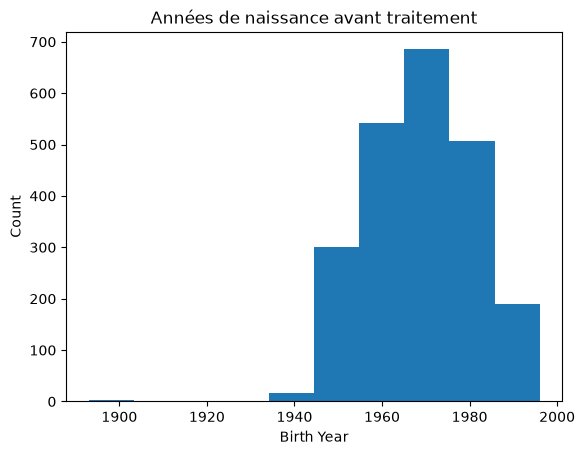

In [7]:
df.Year_Birth.hist()
plt.title('Années de naissance avant traitement')
plt.xlabel('Birth Year')
plt.ylabel('Count')
plt.grid(False)

In [8]:
df[df.Year_Birth < 1940]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
192,7829,1900,2n Cycle,Divorced,36640.0,1,0,26-09-2013,99,15,...,5,0,0,0,0,0,1,3,11,0
239,11004,1893,2n Cycle,Single,60182.0,0,1,17-05-2014,23,8,...,4,0,0,0,0,0,0,3,11,0
339,1150,1899,PhD,Together,83532.0,0,0,26-09-2013,36,755,...,1,0,0,1,0,0,0,3,11,0


Drop Year_Birth < 1920

In [9]:
df.Education.unique()

<StringArray>
['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle']
Length: 5, dtype: str

RàS

In [10]:
df.Marital_Status.unique()

<StringArray>
['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone', 'Absurd',
 'YOLO']
Length: 8, dtype: str

Drop Marital_Status Absurd et YOLO, replace Alone => Single

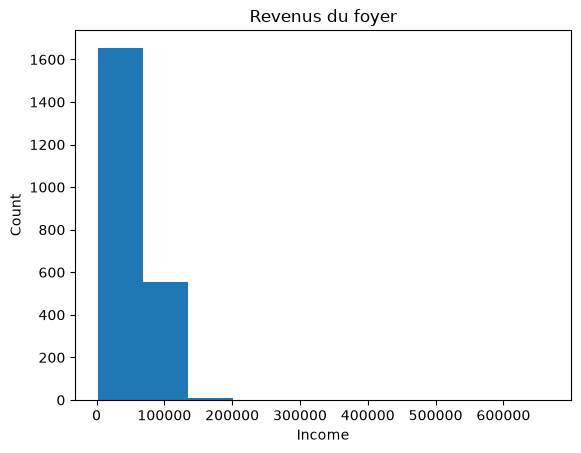

In [11]:
df.Income.hist()
plt.title('Revenus du foyer')
plt.xlabel('Income')
plt.ylabel('Count')
plt.grid(False)

In [12]:
df[df.Income > 120000]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
164,8475,1973,PhD,Married,157243.0,0,1,01-03-2014,98,20,...,0,0,0,0,0,0,0,3,11,0
617,1503,1976,PhD,Together,162397.0,1,1,03-06-2013,31,85,...,1,0,0,0,0,0,0,3,11,0
655,5555,1975,Graduation,Divorced,153924.0,0,0,07-02-2014,81,1,...,0,0,0,0,0,0,0,3,11,0
687,1501,1982,PhD,Married,160803.0,0,0,04-08-2012,21,55,...,0,0,0,0,0,0,0,3,11,0
1300,5336,1971,Master,Together,157733.0,1,0,04-06-2013,37,39,...,1,0,0,0,0,0,0,3,11,0
1653,4931,1977,Graduation,Together,157146.0,0,0,29-04-2013,13,1,...,1,0,0,0,0,0,0,3,11,0
2132,11181,1949,PhD,Married,156924.0,0,0,29-08-2013,85,2,...,0,0,0,0,0,0,0,3,11,0
2233,9432,1977,Graduation,Together,666666.0,1,0,02-06-2013,23,9,...,6,0,0,0,0,0,0,3,11,0


Drop Income 666666

In [13]:
df.Kidhome.unique()

array([0, 1, 2])

RàS

In [14]:
df.Teenhome.unique()

array([0, 1, 2])

RàS

In [15]:
df.Dt_Customer

0       04-09-2012
1       08-03-2014
2       21-08-2013
3       10-02-2014
4       19-01-2014
           ...    
2235    13-06-2013
2236    10-06-2014
2237    25-01-2014
2238    24-01-2014
2239    15-10-2012
Name: Dt_Customer, Length: 2240, dtype: str

In [16]:
Dt = pd.to_datetime(df.Dt_Customer, dayfirst=True)

In [17]:
max(Dt), min(Dt)

(Timestamp('2014-06-29 00:00:00'), Timestamp('2012-07-30 00:00:00'))

RàS

In [18]:
df.Recency.describe()

count    2240.000000
mean       49.109375
std        28.962453
min         0.000000
25%        24.000000
50%        49.000000
75%        74.000000
max        99.000000
Name: Recency, dtype: float64

RàS

In [19]:
df.Complain.unique()

array([0, 1])

RàS

### PRODUCTS DATA EXPLORATION

'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'

In [20]:
df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].describe()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875
std,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000
50%,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000
75%,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000
max,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000


RàS

### PROMOTION DATA EXPLORATION

'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5'

'NumDealsPurchases', 'Response'

In [21]:
df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].describe()

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,0.064286,0.013393,0.072768,0.074554,0.072768
std,0.245316,0.114976,0.259813,0.262728,0.259813
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [22]:
df[['NumDealsPurchases', 'Response']].describe()

,NumDealsPurchases,Response
count,2240.000000,2240.000000
mean,2.325000,0.149107
std,1.932238,0.356274
min,0.000000,0.000000
25%,1.000000,0.000000
50%,2.000000,0.000000
75%,3.000000,0.000000
max,15.000000,1.000000


RàS

### PLACE DATA EXPLORATION

'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth'

In [23]:
df[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']].describe()

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
count,2240.000000,2240.000000,2240.000000,2240.000000
mean,4.084821,2.662054,5.790179,5.316518
std,2.778714,2.923101,3.250958,2.426645
min,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,3.000000,3.000000
50%,4.000000,2.000000,5.000000,6.000000
75%,6.000000,4.000000,8.000000,7.000000
max,27.000000,28.000000,13.000000,20.000000


RàS

## DATA PROCESSING

In [24]:
df_p = df.drop(df[df.Year_Birth < 1920].index)

In [25]:
df_p.drop(df[df.Marital_Status =='Absurd'].index, inplace = True)
df_p.drop(df[df.Marital_Status =='YOLO'].index, inplace = True)
df_p.replace('Alone', 'Single', inplace = True)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [26]:
df_p.drop(df[df.Income == 666666].index, inplace = True)

In [27]:
df_p.dropna(inplace=True)

In [28]:
Dt = pd.to_datetime(df_p.Dt_Customer, dayfirst=True)

In [29]:
df_p.drop(['Dt_Customer'], axis = 1, inplace = True)
df_p = pd.concat([df_p, Dt], axis = 1)

In [30]:
df_p.reset_index(inplace = True)

## DATA VISUALIZATION

In [31]:
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{p:.0f} %\n({v:d})'.format(p=pct,v=val)
    return my_autopct

### PEOPLE DATA VISUALIZATION

'ID', 'Year_Birth', 'Education', 'Marital_Status',  'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'Complain'

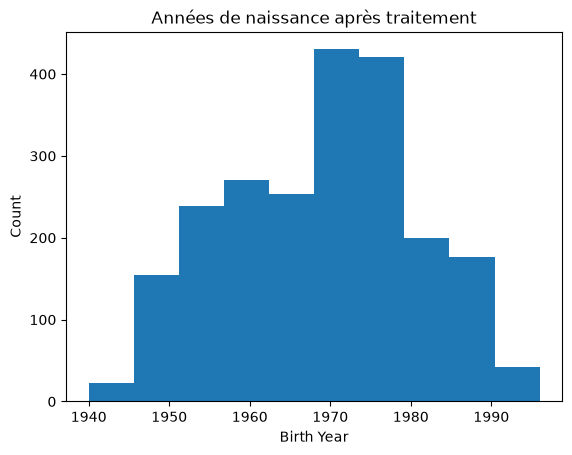

In [32]:
df_p.Year_Birth.hist()
plt.title('Années de naissance après traitement')
plt.xlabel('Birth Year')
plt.ylabel('Count')
plt.grid(False)

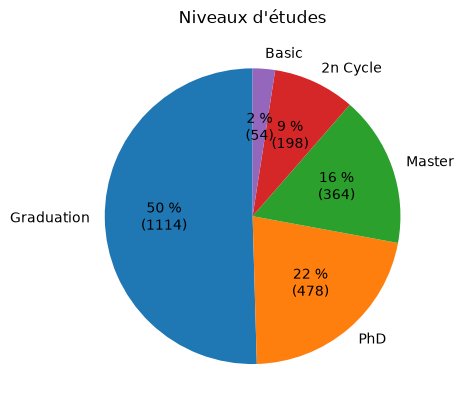

In [33]:
plt.pie(df_p.Education.value_counts(), labels = df_p.Education.value_counts().index, autopct=make_autopct(df_p.Education.value_counts()), startangle = 90)

plt.title('Niveaux d\'études')

plt.show()

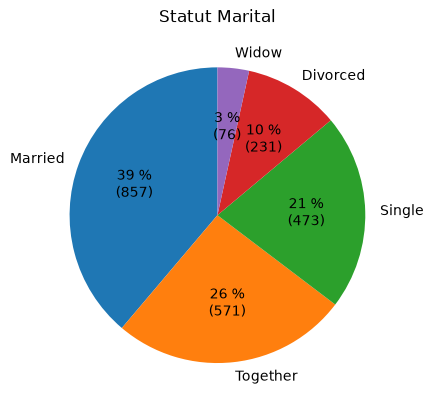

In [34]:
plt.pie(df_p.Marital_Status.value_counts(), labels = df_p.Marital_Status.value_counts().index, autopct=make_autopct(df_p.Marital_Status.value_counts()), startangle = 90)

plt.title('Statut Marital')

plt.show()

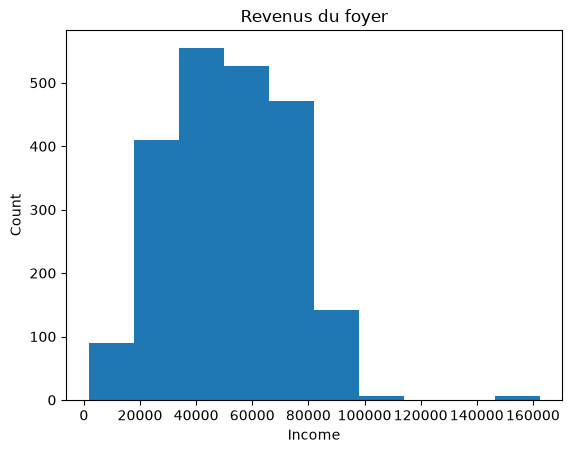

In [35]:
df_p.Income.hist()
plt.title('Revenus du foyer')
plt.xlabel('Income')
plt.ylabel('Count')
plt.grid(False)

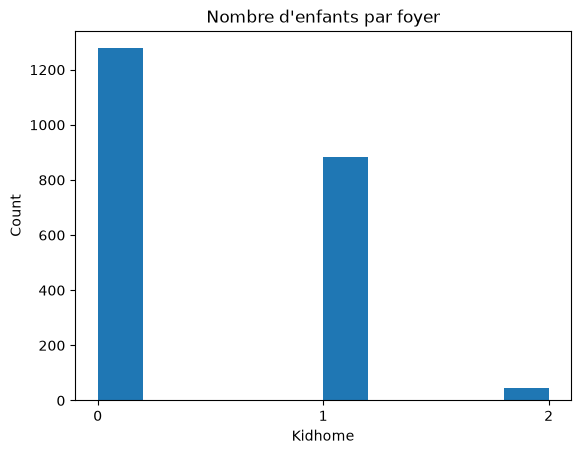

In [36]:
df_p.Kidhome.astype(str).hist()
plt.title('Nombre d\'enfants par foyer')
plt.xlabel('Kidhome')
plt.ylabel('Count')
plt.grid(False)

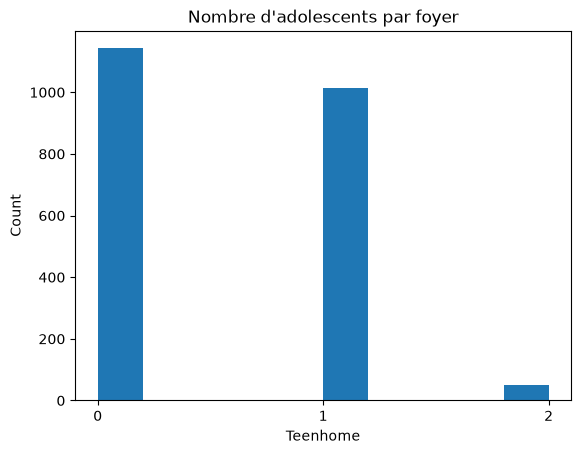

In [37]:
df_p.Teenhome.astype(str).hist()
plt.title('Nombre d\'adolescents par foyer')
plt.xlabel('Teenhome')
plt.ylabel('Count')
plt.grid(False)

In [38]:
Dt_p = pd.to_datetime(df_p.Dt_Customer, dayfirst=True)

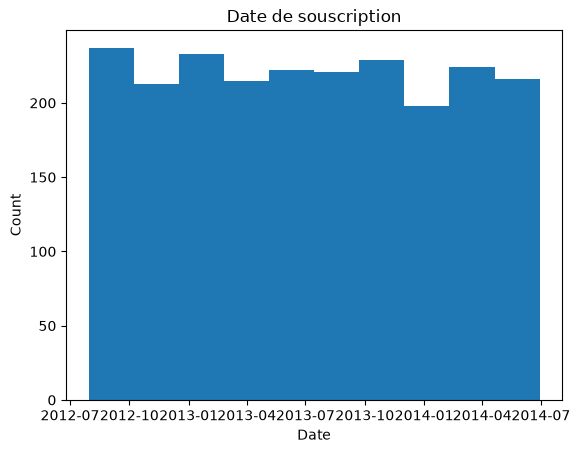

In [39]:
Dt_p.hist()
plt.title('Date de souscription')
plt.xlabel('Date')
plt.ylabel('Count')
plt.grid(False)

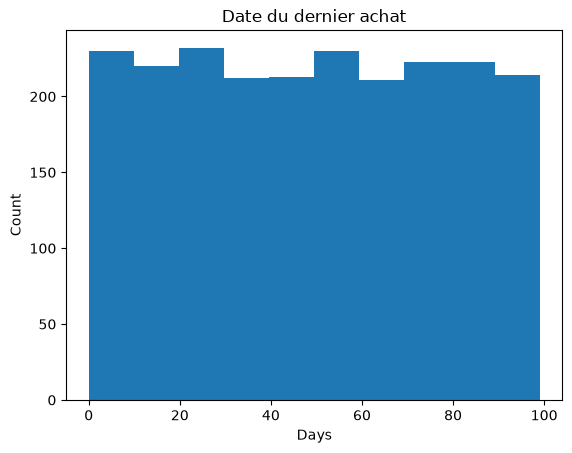

In [40]:
df_p.Recency.hist()
plt.title('Date du dernier achat')
plt.xlabel('Days')
plt.ylabel('Count')
plt.grid(False)

In [41]:
#Complain %
round(df_p.Complain.value_counts(normalize = True)[1] * 100, 2)

np.float64(0.91)

### PRODUCTS DATA VISUALIZATION

'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'

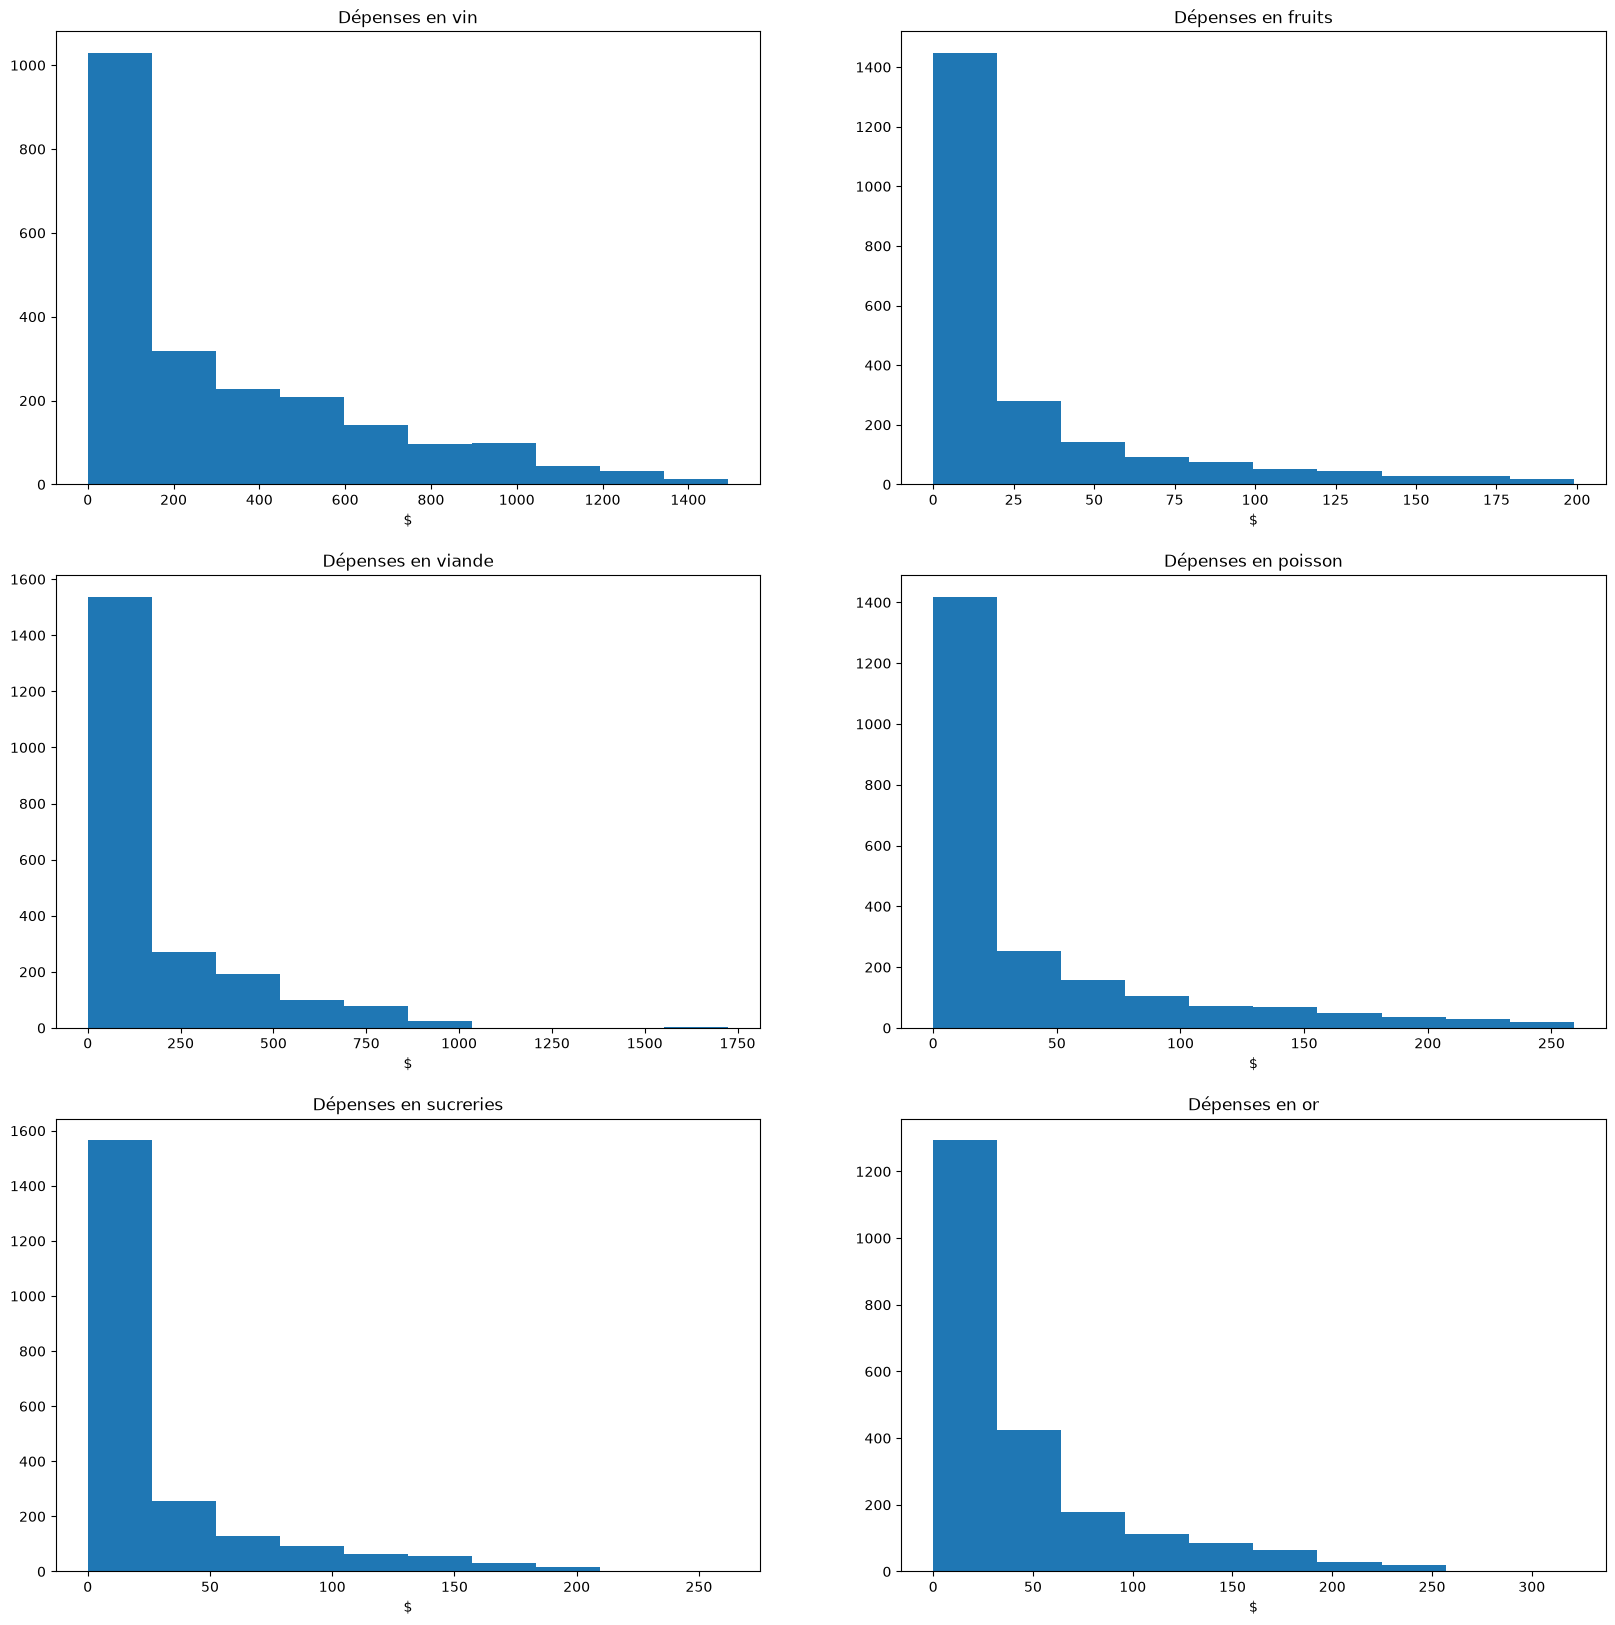

In [42]:
fig = plt.figure(figsize = (20, 20))

plt.subplot(3, 2, 1)
plt.hist(df_p.MntWines)
plt.title('Dépenses en vin')
plt.xlabel('$')

plt.subplot(3, 2, 2)
plt.hist(df_p.MntFruits)
plt.title('Dépenses en fruits')
plt.xlabel('$')

plt.subplot(3, 2, 3)
plt.hist(df_p.MntMeatProducts)
plt.title('Dépenses en viande')
plt.xlabel('$')

plt.subplot(3, 2, 4)
plt.hist(df_p.MntFishProducts)
plt.title('Dépenses en poisson')
plt.xlabel('$')

plt.subplot(3, 2, 5)
plt.hist(df_p.MntSweetProducts)
plt.title('Dépenses en sucreries')
plt.xlabel('$')

plt.subplot(3, 2, 6)
plt.hist(df_p.MntGoldProds)
plt.title('Dépenses en or')
plt.xlabel('$')

plt.show()

### PROMOTION DATA VISUALIZATION

'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5'

'NumDealsPurchases', 'Response'

In [43]:
#Campaign 1 %
print('Taux d\'acceptation lors de la campagne 1 (%):', round(df_p.AcceptedCmp1.value_counts(normalize = True)[1] * 100, 2))

#Campaign 2 %
print('Taux d\'acceptation lors de la campagne 2 (%):', round(df_p.AcceptedCmp2.value_counts(normalize = True)[1] * 100, 2)) 

#Campaign 3 %
print('Taux d\'acceptation lors de la campagne 3 (%):', round(df_p.AcceptedCmp3.value_counts(normalize = True)[1] * 100, 2)) 

#Campaign 4 %
print('Taux d\'acceptation lors de la campagne 4 (%):', round(df_p.AcceptedCmp4.value_counts(normalize = True)[1] * 100, 2)) 

#Campaign 5 %
print('Taux d\'acceptation lors de la campagne 5 (%):', round(df_p.AcceptedCmp5.value_counts(normalize = True)[1] * 100, 2))

Taux d'acceptation lors de la campagne 1 (%): 6.39
Taux d'acceptation lors de la campagne 2 (%): 1.36
Taux d'acceptation lors de la campagne 3 (%): 7.38
Taux d'acceptation lors de la campagne 4 (%): 7.43
Taux d'acceptation lors de la campagne 5 (%): 7.25


Taux d'acceptation lors de la dernière campagne (%): 14.99


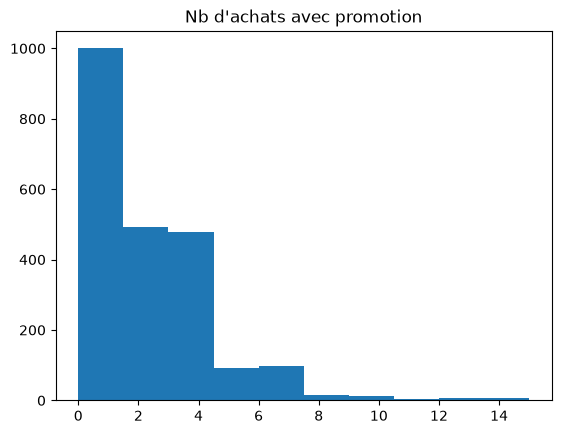

In [44]:
plt.hist(df_p.NumDealsPurchases)
plt.title('Nb d\'achats avec promotion')

print('Taux d\'acceptation lors de la dernière campagne (%):', round(df_p.Response.value_counts(normalize = True)[1] * 100, 2))

### PLACE DATA VISUALIZATION

'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth'

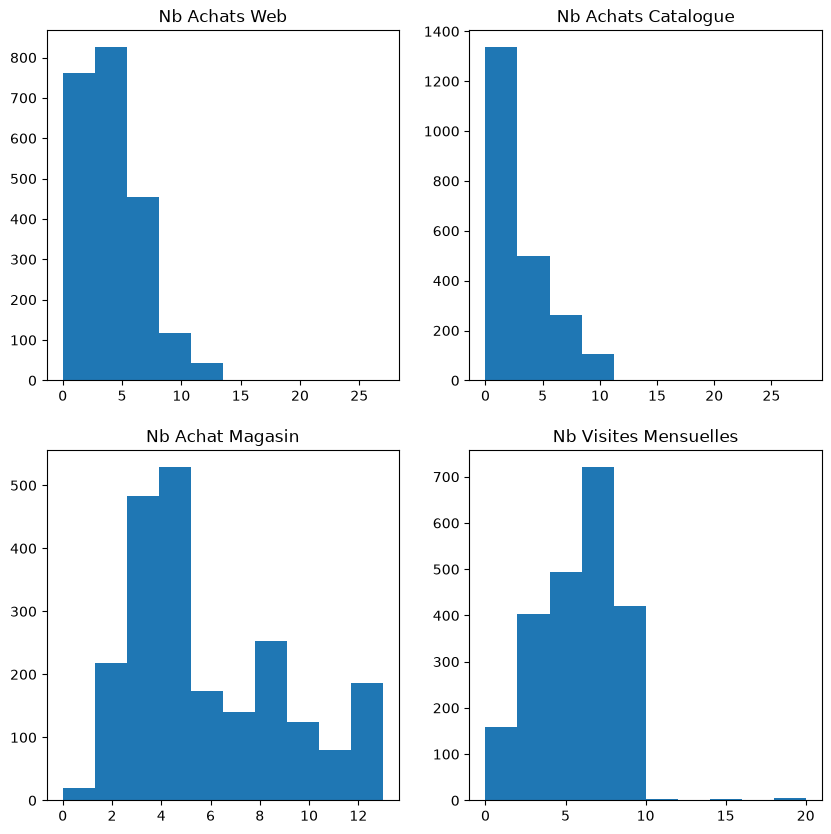

In [45]:
fig = plt.figure(figsize = (10, 10))

plt.subplot(2, 2, 1)
plt.hist(df_p.NumWebPurchases)
plt.title('Nb Achats Web')

plt.subplot(2, 2, 2)
plt.hist(df_p.NumCatalogPurchases)
plt.title('Nb Achats Catalogue')

plt.subplot(2, 2, 3)
plt.hist(df_p.NumStorePurchases)
plt.title('Nb Achat Magasin')

plt.subplot(2, 2, 4)
plt.hist(df_p.NumWebVisitsMonth)
plt.title('Nb Visites Mensuelles')

plt.show()

## CONCLUSION

In [46]:
print(f"Rows : {len(df)} before cleaning / {len(df_p)} after")

Rows : 2240 before cleaning / 2208 after
